In [3]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [4]:
# Training set

training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/'
,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


I0000 00:00:1748244320.783983      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748244320.784661      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [6]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential
from keras.layers import Input

In [7]:
model = Sequential()

# Adding an Input layer
model.add(Input(shape=(128, 128, 3)))

# Building convolution layers
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [8]:
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [9]:
model.add(Conv2D(filters=128, kernel_size=3,padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=256, kernel_size=3,padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [11]:
model.add(Conv2D(filters=512, kernel_size=3,padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [12]:
from keras.layers import Dropout

model.add(Dropout(0.25))


In [13]:
model.add(Flatten())
model.add(Dense(units=1500, activation='relu'))

In [14]:
model.add(Dropout(0.40))

In [15]:
# output layer
model.add(Dense(units=38, activation='softmax'))

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 62, 62, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 31, 31, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 29, 29, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
train_ds = tf.keras.utils.image_dataset_from_directory(
        '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/'
,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
        '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/'
,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    label_mode="categorical"
)


Found 70295 files belonging to 38 classes.
Using 56236 files for training.
Found 70295 files belonging to 38 classes.
Using 14059 files for validation.


In [52]:
import numpy as np
from collections import Counter

# Initialize counter
class_counts = Counter()

# Loop through train_ds to count samples per class
for images, labels in train_ds:
    class_indices = np.argmax(labels.numpy(), axis=1)
    class_counts.update(class_indices)

# Total number of classes
num_classes = len(class_counts)

# Print results
print(f"Total number of classes: {num_classes}")
print("Number of images per class:")
for class_idx in sorted(class_counts):
    print(f"Class {class_idx}: {class_counts[class_idx]} images")


Total number of classes: 38
Number of images per class:
Class 0: 1585 images
Class 1: 1590 images
Class 2: 1400 images
Class 3: 1597 images
Class 4: 1445 images
Class 5: 1328 images
Class 6: 1465 images
Class 7: 1317 images
Class 8: 1540 images
Class 9: 1535 images
Class 10: 1475 images
Class 11: 1486 images
Class 12: 1508 images
Class 13: 1395 images
Class 14: 1347 images
Class 15: 1594 images
Class 16: 1481 images
Class 17: 1409 images
Class 18: 1521 images
Class 19: 1573 images
Class 20: 1536 images
Class 21: 1579 images
Class 22: 1477 images
Class 23: 1425 images
Class 24: 1612 images
Class 25: 1381 images
Class 26: 1383 images
Class 27: 1469 images
Class 28: 1392 images
Class 29: 1552 images
Class 30: 1457 images
Class 31: 1509 images
Class 32: 1412 images
Class 33: 1397 images
Class 34: 1489 images
Class 35: 1590 images
Class 36: 1434 images
Class 37: 1551 images


In [53]:
# Initialize counter
class_counts = Counter()

# Loop through train_ds to count samples per class
for images, labels in test_ds:
    class_indices = np.argmax(labels.numpy(), axis=1)
    class_counts.update(class_indices)

# Total number of classes
num_classes = len(class_counts)

# Print results
print(f"Total number of classes: {num_classes}")
print("Number of images per class:")
for class_idx in sorted(class_counts):
    print(f"Class {class_idx}: {class_counts[class_idx]} images")


Total number of classes: 38
Number of images per class:
Class 0: 431 images
Class 1: 397 images
Class 2: 360 images
Class 3: 411 images
Class 4: 371 images
Class 5: 355 images
Class 6: 361 images
Class 7: 325 images
Class 8: 367 images
Class 9: 373 images
Class 10: 384 images
Class 11: 402 images
Class 12: 412 images
Class 13: 327 images
Class 14: 345 images
Class 15: 416 images
Class 16: 357 images
Class 17: 319 images
Class 18: 392 images
Class 19: 415 images
Class 20: 403 images
Class 21: 360 images
Class 22: 347 images
Class 23: 356 images
Class 24: 410 images
Class 25: 355 images
Class 26: 391 images
Class 27: 355 images
Class 28: 310 images
Class 29: 368 images
Class 30: 394 images
Class 31: 373 images
Class 32: 333 images
Class 33: 344 images
Class 34: 338 images
Class 35: 371 images
Class 36: 356 images
Class 37: 375 images


In [21]:
training_history = model.fit(
    x=train_ds,
    validation_data=validation_set,
    epochs=10,
    steps_per_epoch=len(train_ds),        # number of batches per epoch in training set
    validation_steps=len(validation_set),     # number of batches per epoch in validation set
    shuffle=True                              # shuffling training data each epoch
)

Epoch 1/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 126s 72ms/step - accuracy: 0.4685 - loss: 1.8330 - val_accuracy: 0.8370 - val_loss: 0.5209
Epoch 2/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 109s 62ms/step - accuracy: 0.8178 - loss: 0.5834 - val_accuracy: 0.8806 - val_loss: 0.3713
Epoch 3/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 108s 62ms/step - accuracy: 0.8868 - loss: 0.3553 - val_accuracy: 0.9216 - val_loss: 0.2409
Epoch 4/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 108s 62ms/step - accuracy: 0.9210 - loss: 0.2395 - val_accuracy: 0.9202 - val_loss: 0.2453
Epoch 5/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 108s 62ms/step - accuracy: 0.9421 - loss: 0.1733 - val_accuracy: 0.9348 - val_loss: 0.2173
Epoch 6/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 108s 62ms/step - accuracy: 0.9533 - loss: 0.1408 - val_accuracy: 0.9453 - val_loss: 0.1767
Epoch 7/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 108s 61ms/step - accuracy: 0.9627 - loss: 0.1135 - val_accuracy: 0.9522 - val_loss: 0.1519
Epoch 8/10
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 108s 62ms/step - accuracy: 

In [22]:
model.save("trained_model.keras")

In [23]:
training_history.history

{'accuracy': [0.6186962127685547,
  0.8392844200134277,
  0.897592306137085,
  0.9286933541297913,
  0.9474357962608337,
  0.9578917622566223,
  0.9654669761657715,
  0.9712284207344055,
  0.9763674736022949,
  0.9783235192298889],
 'loss': [1.2767632007598877,
  0.5087847113609314,
  0.31908202171325684,
  0.21701844036579132,
  0.15880532562732697,
  0.1281915158033371,
  0.10598848015069962,
  0.08630166202783585,
  0.07170148938894272,
  0.06884098798036575],
 'val_accuracy': [0.8370134234428406,
  0.8806055188179016,
  0.921636700630188,
  0.9201570749282837,
  0.9348395466804504,
  0.9452537894248962,
  0.9521966576576233,
  0.9511154294013977,
  0.9418392777442932,
  0.9465057849884033],
 'val_loss': [0.5209431052207947,
  0.37131479382514954,
  0.24094009399414062,
  0.24530284106731415,
  0.2173192948102951,
  0.17669790983200073,
  0.15188845992088318,
  0.15360315144062042,
  0.20702596008777618,
  0.19318260252475739]}

In [24]:
#Recording History in json

import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

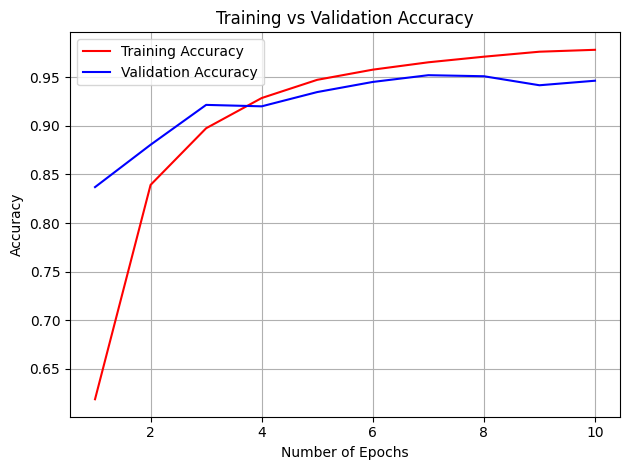

In [25]:
import matplotlib.pyplot as plt

epochs = range(1, len(training_history.history['accuracy']) + 1)
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
model.evaluate(test_ds)

440/440 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9441 - loss: 0.1950


[0.19652453064918518, 0.9450885653495789]


Precision, Recall, F1-score:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.91      0.93       431
                                 Apple___Black_rot       0.98      0.96      0.97       397
                          Apple___Cedar_apple_rust       0.90      0.98      0.94       360
                                   Apple___healthy       0.98      0.82      0.89       411
                               Blueberry___healthy       0.86      0.96      0.91       371
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       355
                 Cherry_(including_sour)___healthy       0.94      0.99      0.96       361
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.90      0.92       325
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       367
               Corn_(maize)___Northern_Leaf_Blig

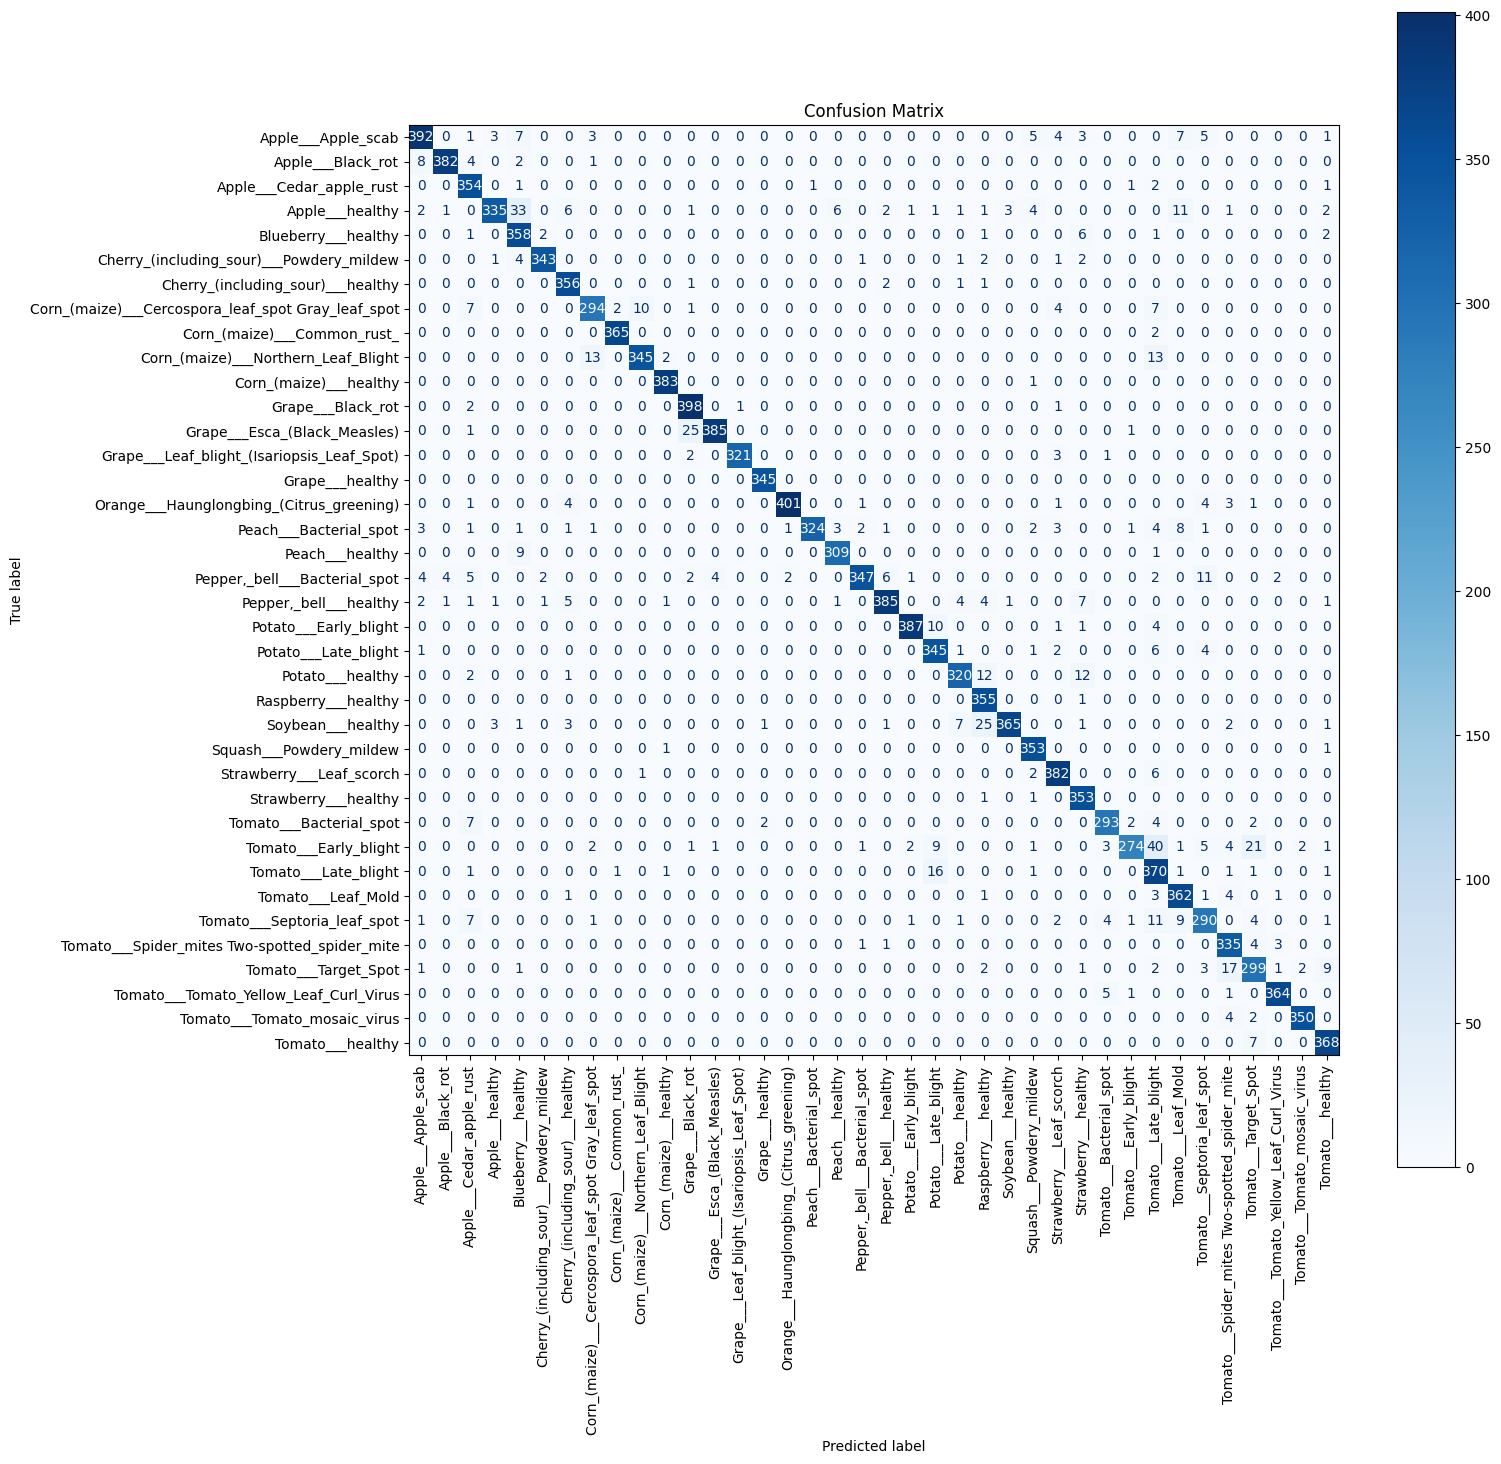

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get class names from train_ds
class_names = train_ds.class_names

y_true = []
y_pred = []

# Collect predictions
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report (precision, recall, F1)
report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
print("\nPrecision, Recall, F1-score:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


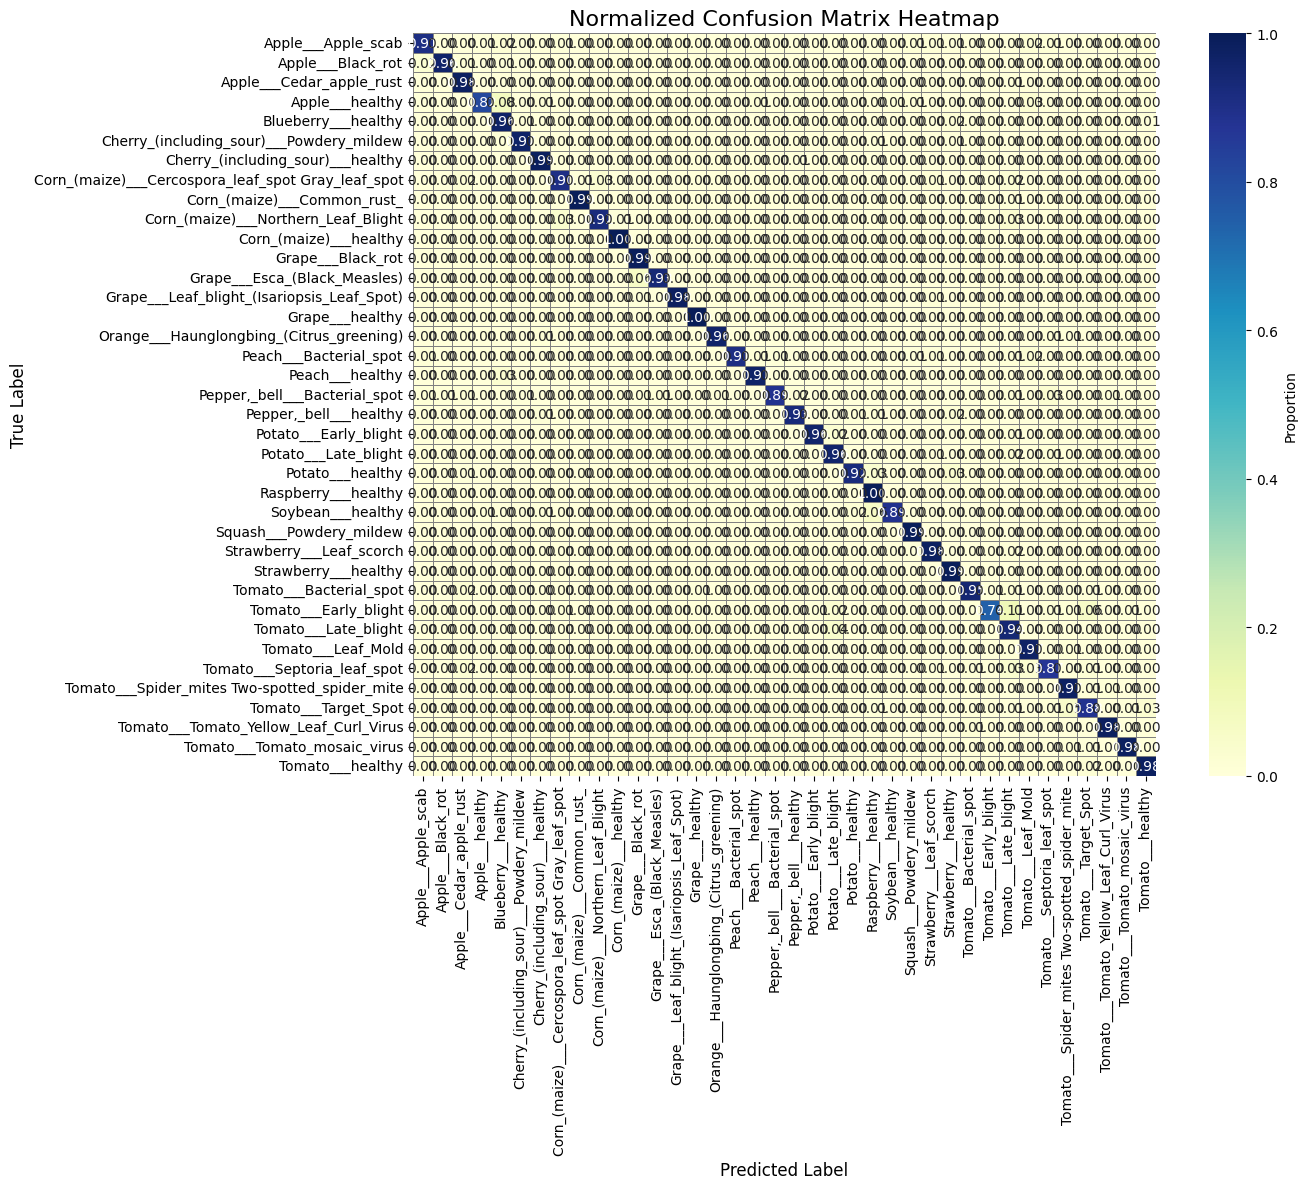

In [49]:
import seaborn as sns

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt=".2f", 
            cmap="YlGnBu", 
            xticklabels=class_names, 
            yticklabels=class_names,
            square=True, 
            cbar_kws={'label': 'Proportion'},
            linewidths=0.5, 
            linecolor='gray')

plt.title("Normalized Confusion Matrix Heatmap", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
